# Chapter 3: Classification

## Introduction

In this notebook, we'll explore **classification** in Machine Learning. Unlike regression which predicts continuous values, classification predicts discrete classes or categories.

We'll use the famous **MNIST dataset** of handwritten digits to learn about:
- Binary classification
- Performance metrics (accuracy, precision, recall, F1 score)
- Confusion matrices
- ROC curves
- Multiclass classification
- Error analysis

## 1. Loading and Exploring the MNIST Dataset

The MNIST dataset contains 70,000 images of handwritten digits (0-9). Each image is 28×28 pixels, which gives us 784 features per image. Each pixel's intensity ranges from 0 (white) to 255 (black).

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load the MNIST dataset
print("Loading MNIST dataset... This may take a minute.")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
print("Dataset loaded successfully!")
print(f"\nDataset keys: {mnist.keys()}")

Loading MNIST dataset... This may take a minute.
Dataset loaded successfully!

Dataset keys: dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
Dataset loaded successfully!

Dataset keys: dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
# Extract features (X) and labels (y)
X, y = mnist["data"], mnist["target"]

print(f"Features shape: {X.shape}")  # (70000, 784)
print(f"Labels shape: {y.shape}")    # (70000,)
print(f"\nFirst 10 labels: {y[:10].values}")

Features shape: (70000, 784)
Labels shape: (70000,)

First 10 labels: ['5', '0', '4', '1', '9', '2', '1', '3', '1', '4']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


### Visualizing Digits

Let's create a helper function to visualize the handwritten digits and look at some examples.

In [4]:
def plot_digit(data):
    """Plot a single digit image."""
    image = data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def plot_digits(instances, images_per_row=10, **options):
    """Plot multiple digit images in a grid."""
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row:(row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")

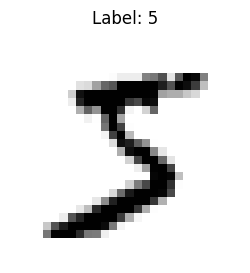

This digit is: 5


In [5]:
# Visualize a single digit
some_digit = X.iloc[0].values if hasattr(X, 'iloc') else X[0]
plt.figure(figsize=(3, 3))
plot_digit(some_digit)
plt.title(f"Label: {y[0]}")
plt.show()

print(f"This digit is: {y[0]}")

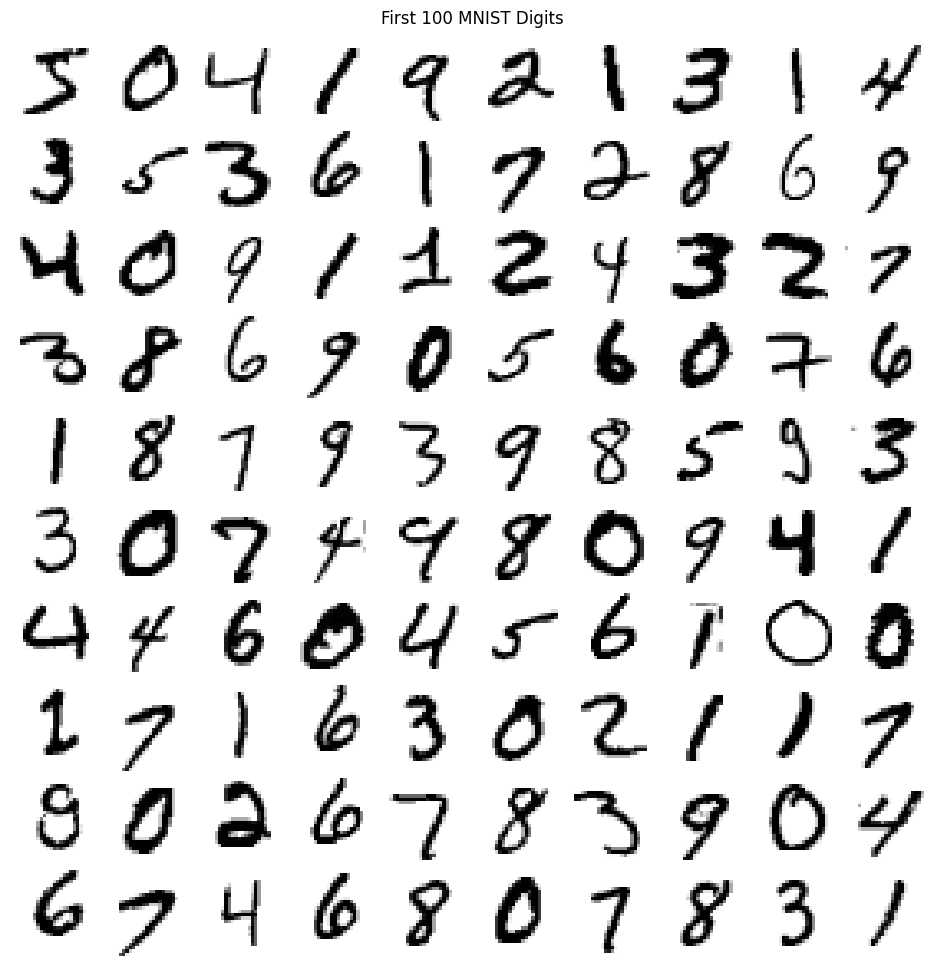

In [6]:
# Visualize the first 100 digits
plt.figure(figsize=(12, 12))
example_images = X[:100].values if hasattr(X, 'values') else X[:100]
plot_digits(example_images, images_per_row=10)
plt.title("First 100 MNIST Digits")
plt.show()

### Preparing the Data

Let's convert the data to the right format and split it into training and test sets.

In [7]:
# Convert to numpy arrays and ensure correct types
X = X.values if hasattr(X, 'values') else X
y = y.values if hasattr(y, 'values') else y
y = y.astype(np.uint8)  # Convert labels to integers

# Split into training and test sets (first 60,000 for training)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nThe training set is already shuffled, which is good for cross-validation!")

Training set size: (60000, 784)
Test set size: (10000, 784)

The training set is already shuffled, which is good for cross-validation!


## 2. Binary Classification

Let's start with a simpler problem: **binary classification**. We'll build a classifier that detects whether a digit is a "5" or not.

This simplifies our 10-class problem into a binary problem (5 vs not-5).

In [8]:
# Create binary target vectors (True for 5s, False for others)
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

print(f"Number of 5s in training set: {y_train_5.sum()}")
print(f"Number of non-5s in training set: {(~y_train_5).sum()}")
print(f"\nPercentage of 5s: {y_train_5.sum() / len(y_train_5) * 100:.2f}%")

Number of 5s in training set: 5421
Number of non-5s in training set: 54579

Percentage of 5s: 9.04%


### Training an SGD Classifier

**Stochastic Gradient Descent (SGD) Classifier** is efficient for large datasets because it processes instances independently. It's well-suited for online learning.

In [9]:
from sklearn.linear_model import SGDClassifier

# Create and train the classifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Test it on our example digit
prediction = sgd_clf.predict([some_digit])
print(f"Prediction for the first digit: {prediction[0]}")
print(f"Actual label: {y_train_5[0]}")
print(f"\nThe classifier correctly predicts it's a 5!" if prediction[0] else "Incorrect prediction.")

Prediction for the first digit: True
Actual label: True

The classifier correctly predicts it's a 5!


## 3. Performance Measures

### 3.1 Cross-Validation with Accuracy

**Cross-validation** splits the training set into folds, trains on some folds, and validates on the remaining fold. This is repeated for each fold.

In [10]:
from sklearn.model_selection import cross_val_score

# Evaluate using 3-fold cross-validation
scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")

Cross-validation accuracy scores: [0.95035 0.96035 0.9604 ]
Mean accuracy: 0.9570
Standard deviation: 0.0047


### Why Accuracy Can Be Misleading

With imbalanced datasets (only ~9% are 5s), a classifier that always predicts "not 5" would achieve ~91% accuracy!

In [11]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    """A dummy classifier that always predicts 'not 5'."""
    def fit(self, X, y=None):
        return self
    
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
never_scores = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

print(f"'Never 5' classifier accuracy: {never_scores}")
print(f"Mean accuracy: {never_scores.mean():.4f}")
print(f"\nThis demonstrates why accuracy alone is not a good metric for imbalanced datasets!")

'Never 5' classifier accuracy: [0.91125 0.90855 0.90915]
Mean accuracy: 0.9096

This demonstrates why accuracy alone is not a good metric for imbalanced datasets!


### 3.2 Confusion Matrix

A **confusion matrix** shows the counts of:
- **True Negatives (TN)**: Correctly predicted negatives
- **False Positives (FP)**: Incorrectly predicted as positive
- **False Negatives (FN)**: Incorrectly predicted as negative
- **True Positives (TP)**: Correctly predicted positives

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Get predictions for all training instances using cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

# Compute confusion matrix
conf_mx = confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:")
print(conf_mx)
print(f"\nInterpretation:")
print(f"True Negatives (TN): {conf_mx[0, 0]:,} - Correctly classified as non-5")
print(f"False Positives (FP): {conf_mx[0, 1]:,} - Incorrectly classified as 5")
print(f"False Negatives (FN): {conf_mx[1, 0]:,} - Incorrectly classified as non-5")
print(f"True Positives (TP): {conf_mx[1, 1]:,} - Correctly classified as 5")

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]

Interpretation:
True Negatives (TN): 53,892 - Correctly classified as non-5
False Positives (FP): 687 - Incorrectly classified as 5
False Negatives (FN): 1,891 - Incorrectly classified as non-5
True Positives (TP): 3,530 - Correctly classified as 5


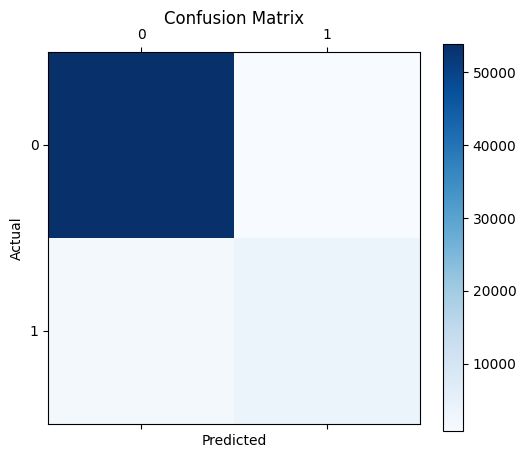

In [13]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
plt.matshow(conf_mx, cmap=plt.cm.Blues, fignum=1)
plt.title("Confusion Matrix", pad=20)
plt.colorbar()
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 3.3 Precision and Recall

**Precision**: What proportion of positive predictions are correct?
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall** (Sensitivity): What proportion of actual positives are detected?
$$\text{Recall} = \frac{TP}{TP + FN}$$

In [14]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"\nInterpretation:")
print(f"- {precision*100:.1f}% of images predicted as '5' are actually 5s")
print(f"- {recall*100:.1f}% of actual 5s are detected by the classifier")

Precision: 0.8371 (83.71%)
Recall: 0.6512 (65.12%)

Interpretation:
- 83.7% of images predicted as '5' are actually 5s
- 65.1% of actual 5s are detected by the classifier


### 3.4 F₁ Score

The **F₁ score** is the harmonic mean of precision and recall. It's useful when you need a single metric that balances both.

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [15]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)
print(f"F₁ Score: {f1:.4f}")
print(f"\nThe F₁ score favors classifiers with similar precision and recall.")

F₁ Score: 0.7325

The F₁ score favors classifiers with similar precision and recall.


### 3.5 Precision/Recall Trade-off

The SGD classifier computes a decision score for each instance. By adjusting the threshold, we can trade precision for recall (or vice versa).

- **High threshold**: Higher precision, lower recall
- **Low threshold**: Lower precision, higher recall

In [16]:
# Get decision scores for all training instances
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

print(f"Decision score for our example digit: {sgd_clf.decision_function([some_digit])[0]:.2f}")
print(f"\nWith default threshold (0): Predicted as {sgd_clf.predict([some_digit])[0]}")

# Try different thresholds
threshold_8000 = (y_scores > 8000)
print(f"With threshold 8000: Predicted as {threshold_8000[0]}")

Decision score for our example digit: 2164.22

With default threshold (0): Predicted as True
With threshold 8000: Predicted as False


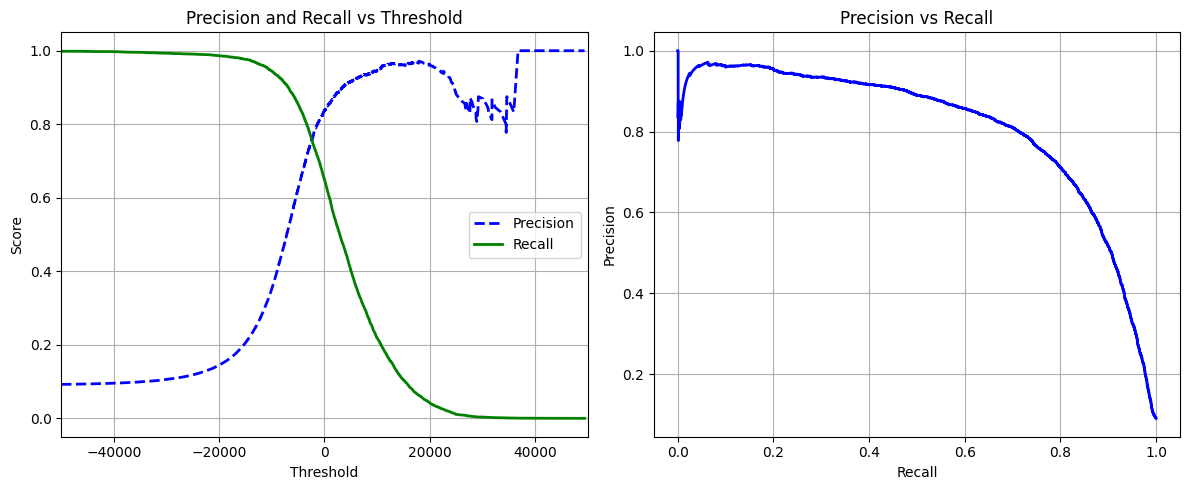

In [17]:
from sklearn.metrics import precision_recall_curve

# Compute precision and recall for all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Plot precision and recall vs threshold
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.xlim([-50000, 50000])

# Plot precision vs recall
plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, "b-", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.grid(True)

plt.tight_layout()
plt.show()

### Selecting a Threshold for 90% Precision

Let's find the threshold that gives us at least 90% precision.

In [18]:
# Find threshold for 90% precision
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
print(f"Threshold for 90% precision: {threshold_90_precision:.2f}")

# Make predictions with this threshold
y_train_pred_90 = (y_scores >= threshold_90_precision)

precision_90 = precision_score(y_train_5, y_train_pred_90)
recall_90 = recall_score(y_train_5, y_train_pred_90)

print(f"\nWith threshold {threshold_90_precision:.2f}:")
print(f"Precision: {precision_90:.4f} ({precision_90*100:.2f}%)")
print(f"Recall: {recall_90:.4f} ({recall_90*100:.2f}%)")
print(f"\nTrade-off: We achieve high precision but lower recall!")

Threshold for 90% precision: 3370.02

With threshold 3370.02:
Precision: 0.9000 (90.00%)
Recall: 0.4800 (48.00%)

Trade-off: We achieve high precision but lower recall!


### 3.6 ROC Curve

The **Receiver Operating Characteristic (ROC) curve** plots:
- **True Positive Rate (TPR)** = Recall on the y-axis
- **False Positive Rate (FPR)** on the x-axis

$$\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$

A perfect classifier has ROC AUC = 1, while a random classifier has ROC AUC = 0.5.

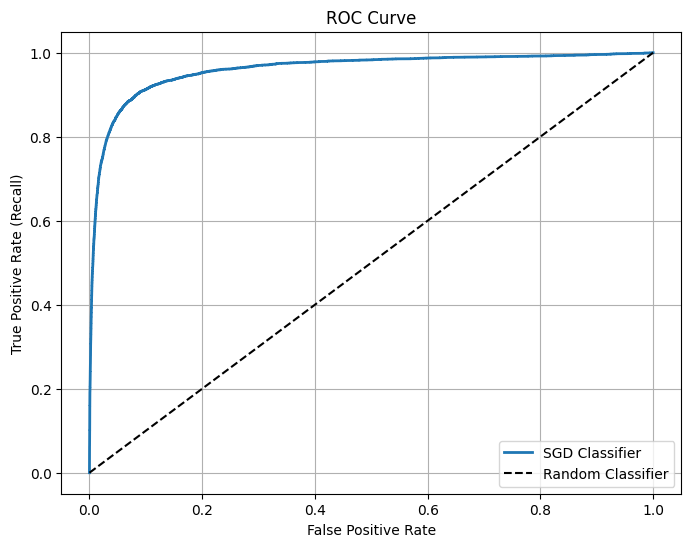

ROC AUC Score: 0.9605

A good classifier stays far from the diagonal (toward top-left corner).


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label="SGD Classifier")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Compute ROC AUC score
roc_auc = roc_auc_score(y_train_5, y_scores)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"\nA good classifier stays far from the diagonal (toward top-left corner).")

### 3.7 Comparing with Random Forest Classifier

Let's compare the SGD classifier with a **Random Forest classifier**.

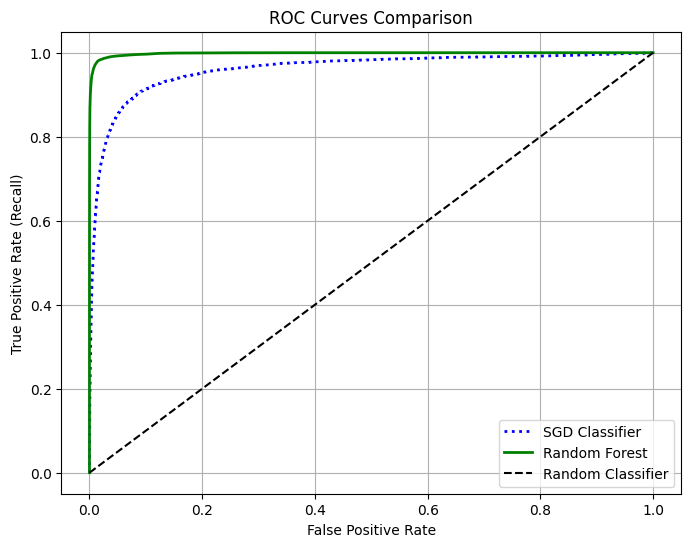

SGD Classifier ROC AUC: 0.9605
Random Forest ROC AUC: 0.9983

Random Forest significantly outperforms SGD!


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest classifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

# Get probability scores for positive class
y_scores_forest = y_probas_forest[:, 1]

# Compute ROC curve for Random Forest
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD Classifier")
plt.plot(fpr_forest, tpr_forest, "g-", linewidth=2, label="Random Forest")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Compare ROC AUC scores
roc_auc_forest = roc_auc_score(y_train_5, y_scores_forest)
print(f"SGD Classifier ROC AUC: {roc_auc:.4f}")
print(f"Random Forest ROC AUC: {roc_auc_forest:.4f}")
print(f"\nRandom Forest significantly outperforms SGD!")

In [21]:
# Get predictions from Random Forest
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)

print("Random Forest Performance:")
print(f"Precision: {precision_score(y_train_5, y_train_pred_forest):.4f}")
print(f"Recall: {recall_score(y_train_5, y_train_pred_forest):.4f}")
print(f"F₁ Score: {f1_score(y_train_5, y_train_pred_forest):.4f}")

Random Forest Performance:
Precision: 0.9905
Recall: 0.8663
F₁ Score: 0.9242


## 4. Multiclass Classification

Now let's tackle the full problem: classifying all 10 digits (0-9).

### Strategies:
1. **One-vs-Rest (OvR)**: Train N binary classifiers, one per class
2. **One-vs-One (OvO)**: Train N×(N-1)/2 classifiers, one for each pair of classes

Most algorithms use OvR by default. Scikit-Learn automatically detects multiclass and chooses the appropriate strategy.

In [22]:
from sklearn.svm import SVC

# Train SVM classifier (uses OvO strategy by default)
print("Training SVM classifier... This may take a minute.")
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:5000], y_train[:5000])  # Using subset for speed
print("Training complete!")

# Test prediction
prediction = svm_clf.predict([some_digit])
print(f"\nPrediction: {prediction[0]}")
print(f"Actual: {y[0]}")

Training SVM classifier... This may take a minute.
Training complete!

Prediction: 5
Actual: 5
Training complete!

Prediction: 5
Actual: 5


In [23]:
# Get decision scores for all classes
some_digit_scores = svm_clf.decision_function([some_digit])
print(f"Decision scores for all classes: {some_digit_scores[0]}")
print(f"\nHighest score class: {np.argmax(some_digit_scores)}")
print(f"Classes: {svm_clf.classes_}")

Decision scores for all classes: [ 0.74425472  2.744763    6.1874606   8.29544346 -0.3001552   9.30508656
  1.74544703  4.79018461  7.19991924  3.84775475]

Highest score class: 5
Classes: [0 1 2 3 4 5 6 7 8 9]


### Training SGD Classifier for Multiclass

SGD classifiers can handle multiple classes natively.

In [24]:
# Train SGD for multiclass classification
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

prediction = sgd_clf.predict([some_digit])
print(f"SGD Prediction: {prediction[0]}")
print(f"Actual: {y[0]}")

# Get decision scores
scores = sgd_clf.decision_function([some_digit])
print(f"\nDecision scores: {scores[0]}")

SGD Prediction: 3
Actual: 5

Decision scores: [-31893.03095419 -34419.69069632  -9530.63950739   1823.73154031
 -22320.14822878  -1385.80478895 -26188.91070951 -16147.51323997
  -4604.35491274 -12050.767298  ]


### Evaluating Multiclass Classifier

In [25]:
# Evaluate with cross-validation
scores = cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f}")

Cross-validation scores: [0.87365 0.85835 0.8689 ]
Mean accuracy: 0.8670


### Improving with Feature Scaling

Many ML algorithms perform better with scaled features. Let's use **StandardScaler** to standardize the features.

In [26]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

# Evaluate with scaled data
scores_scaled = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")
print(f"Cross-validation scores (with scaling): {scores_scaled}")
print(f"Mean accuracy: {scores_scaled.mean():.4f}")
print(f"\nImprovement: {(scores_scaled.mean() - scores.mean())*100:.2f} percentage points!")

Cross-validation scores (with scaling): [0.8983 0.891  0.9018]
Mean accuracy: 0.8970

Improvement: 3.01 percentage points!


## 5. Error Analysis

Let's analyze what types of errors our classifier makes. This can help us improve the model.

In [27]:
# Get predictions for the entire training set
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

# Compute confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix shape:", conf_mx.shape)
print("\nFirst few rows of confusion matrix:")
print(conf_mx[:5, :])

Confusion Matrix shape: (10, 10)

First few rows of confusion matrix:
[[5577    0   22    5    8   43   36    6  225    1]
 [   0 6400   37   24    4   44    4    7  212   10]
 [  27   27 5220   92   73   27   67   36  378   11]
 [  22   17  117 5227    2  203   27   40  403   73]
 [  12   14   41    9 5182   12   34   27  347  164]]


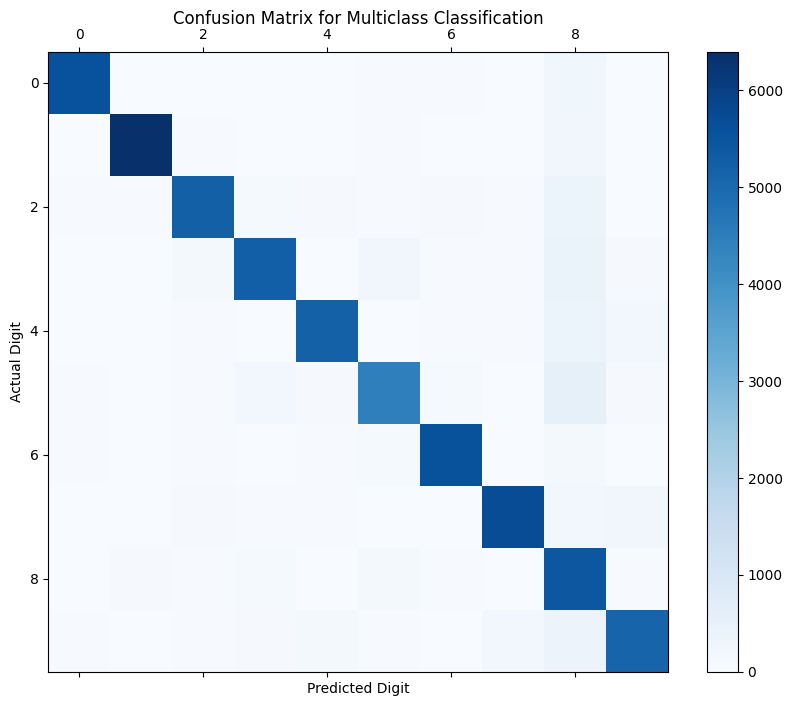

The diagonal shows correct predictions.
Off-diagonal elements show errors.


In [28]:
# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
plt.matshow(conf_mx, cmap=plt.cm.Blues, fignum=1)
plt.title("Confusion Matrix for Multiclass Classification", pad=20)
plt.colorbar()
plt.ylabel("Actual Digit")
plt.xlabel("Predicted Digit")
plt.show()

print("The diagonal shows correct predictions.")
print("Off-diagonal elements show errors.")

### Analyzing Error Rates

Let's normalize the confusion matrix to see error rates rather than absolute counts.

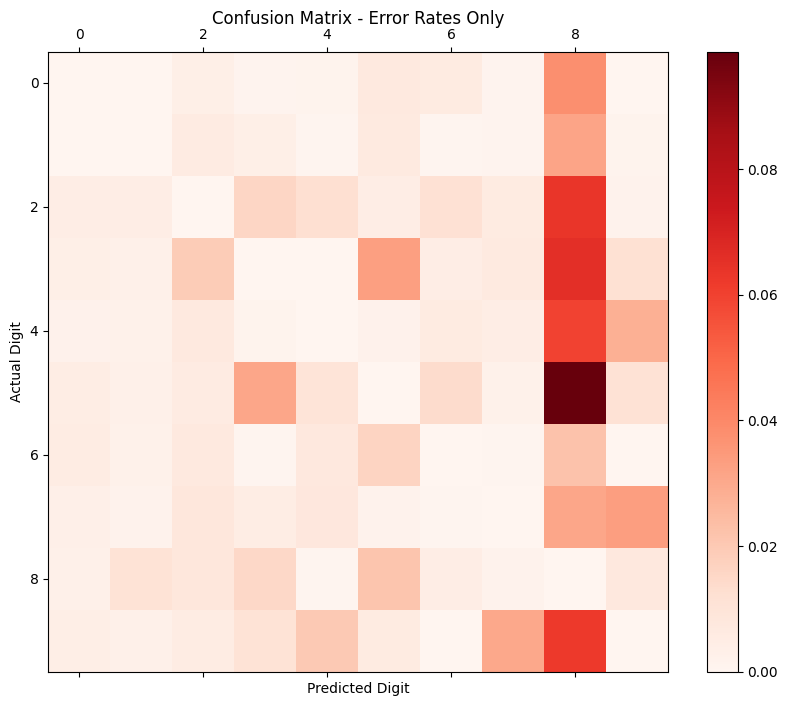

Bright columns indicate digits that are often misclassified.
Bright rows indicate digits that are frequently confused with others.


In [29]:
# Normalize by row (actual class)
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

# Fill diagonal with zeros to focus on errors
np.fill_diagonal(norm_conf_mx, 0)

# Visualize error rates
plt.figure(figsize=(10, 8))
plt.matshow(norm_conf_mx, cmap=plt.cm.Reds, fignum=1)
plt.title("Confusion Matrix - Error Rates Only", pad=20)
plt.colorbar()
plt.ylabel("Actual Digit")
plt.xlabel("Predicted Digit")
plt.show()

print("Bright columns indicate digits that are often misclassified.")
print("Bright rows indicate digits that are frequently confused with others.")

### Analyzing Specific Errors: 3s vs 5s

Let's look at examples where 3s and 5s are confused.

In [30]:
# Find instances of 3s and 5s
cl_a, cl_b = 3, 5

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]  # 3s predicted as 3
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]  # 3s predicted as 5
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]  # 5s predicted as 3
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]  # 5s predicted as 5

print(f"3s correctly classified: {len(X_aa)}")
print(f"3s misclassified as 5s: {len(X_ab)}")
print(f"5s misclassified as 3s: {len(X_ba)}")
print(f"5s correctly classified: {len(X_bb)}")

3s correctly classified: 5227
3s misclassified as 5s: 203
5s misclassified as 3s: 168
5s correctly classified: 4444


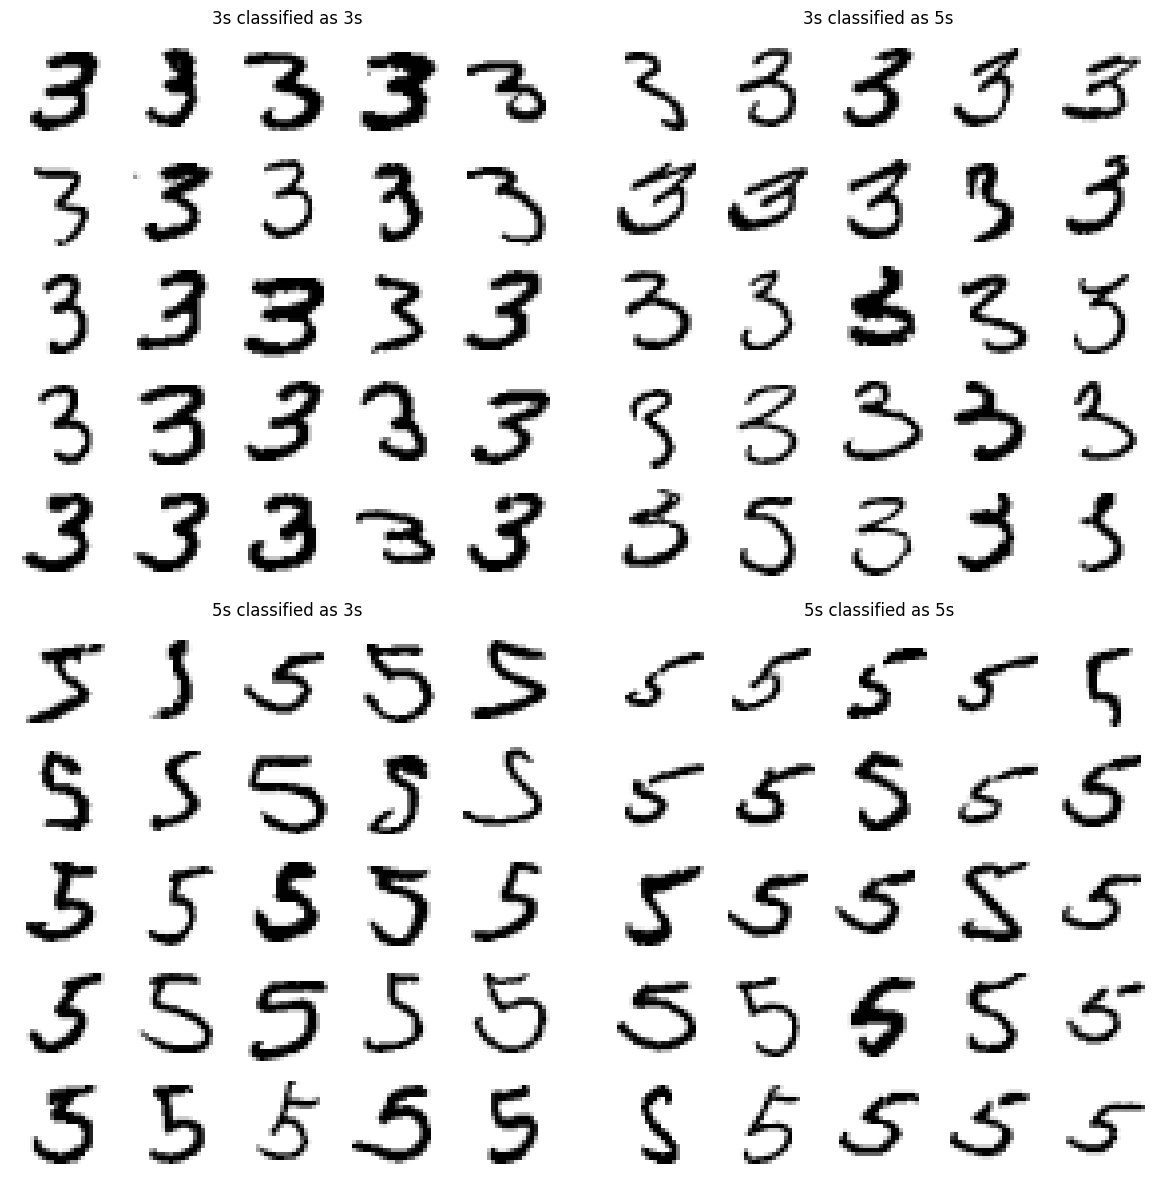


Observation: The misclassified digits often have poor handwriting or unusual styles.
Linear models like SGD struggle with these variations.


In [31]:
# Visualize the confusion between 3s and 5s
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plot_digits(X_aa[:25], images_per_row=5)
plt.title("3s classified as 3s")

plt.subplot(2, 2, 2)
plot_digits(X_ab[:25], images_per_row=5)
plt.title("3s classified as 5s")

plt.subplot(2, 2, 3)
plot_digits(X_ba[:25], images_per_row=5)
plt.title("5s classified as 3s")

plt.subplot(2, 2, 4)
plot_digits(X_bb[:25], images_per_row=5)
plt.title("5s classified as 5s")

plt.tight_layout()
plt.show()

print("\nObservation: The misclassified digits often have poor handwriting or unusual styles.")
print("Linear models like SGD struggle with these variations.")

## 6. Multilabel Classification

**Multilabel classification** outputs multiple binary labels per instance.

Example: Detect if a digit is:
- Large (≥ 7)
- Odd

In [32]:
from sklearn.neighbors import KNeighborsClassifier

# Create multilabel targets
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

print(f"Example labels for first 10 digits:")
print(f"Digits: {y_train[:10]}")
print(f"[Large, Odd]: {y_multilabel[:10]}")

Example labels for first 10 digits:
Digits: [5 0 4 1 9 2 1 3 1 4]
[Large, Odd]: [[False  True]
 [False False]
 [False False]
 [False  True]
 [ True  True]
 [False False]
 [False  True]
 [False  True]
 [False  True]
 [False False]]


In [33]:
# Train KNN classifier for multilabel classification
print("Training KNN classifier...")
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
print("Training complete!")

# Test on our example digit (5)
prediction = knn_clf.predict([some_digit])
print(f"\nPrediction for digit {y[0]}: {prediction[0]}")
print(f"[Large (≥7), Odd]")
print(f"\nThe digit 5 is correctly identified as: not large, but odd!")

Training KNN classifier...
Training complete!
Training complete!

Prediction for digit 5: [False  True]
[Large (≥7), Odd]

The digit 5 is correctly identified as: not large, but odd!

Prediction for digit 5: [False  True]
[Large (≥7), Odd]

The digit 5 is correctly identified as: not large, but odd!


In [34]:
# Evaluate multilabel classifier
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1 = f1_score(y_multilabel, y_train_knn_pred, average="macro")

print(f"F₁ Score (macro average): {f1:.4f}")
print(f"\nThis averages F₁ scores across all labels with equal weight.")

F₁ Score (macro average): 0.9764

This averages F₁ scores across all labels with equal weight.


## 7. Multioutput Classification

**Multioutput-multiclass classification** is a generalization where each label can have multiple values.

Example: Remove noise from images (each pixel is a label with 256 possible values).

In [35]:
# Add noise to training images
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

noise_test = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test

# The target is the original clean image
y_train_mod = X_train
y_test_mod = X_test

print("Created noisy versions of the images.")
print(f"Training set: {X_train_mod.shape}")

Created noisy versions of the images.
Training set: (60000, 784)


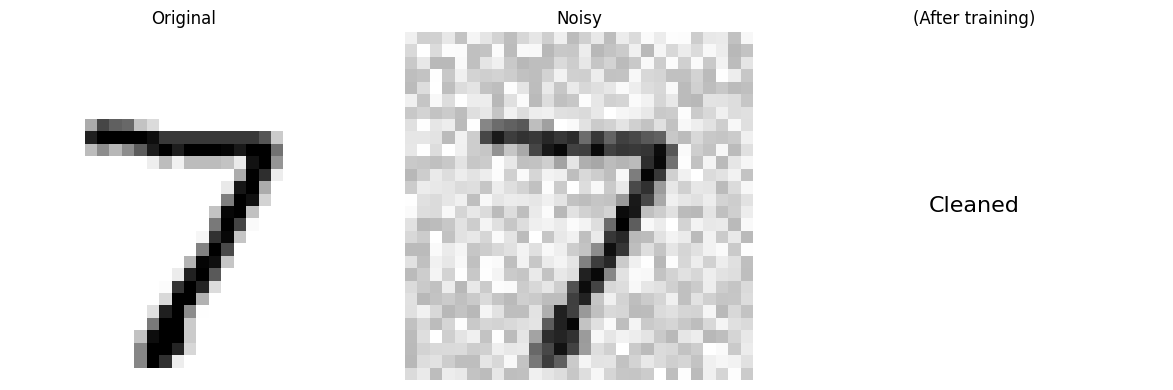

In [36]:
# Visualize noisy vs clean images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plot_digit(X_test[0])
plt.title("Original")

plt.subplot(1, 3, 2)
plot_digit(X_test_mod[0])
plt.title("Noisy")

plt.subplot(1, 3, 3)
plt.text(0.5, 0.5, "Cleaned", ha='center', va='center', fontsize=16)
plt.axis('off')
plt.title("(After training)")

plt.tight_layout()
plt.show()

Training noise removal classifier... This will take a while.
Training complete!
Training complete!


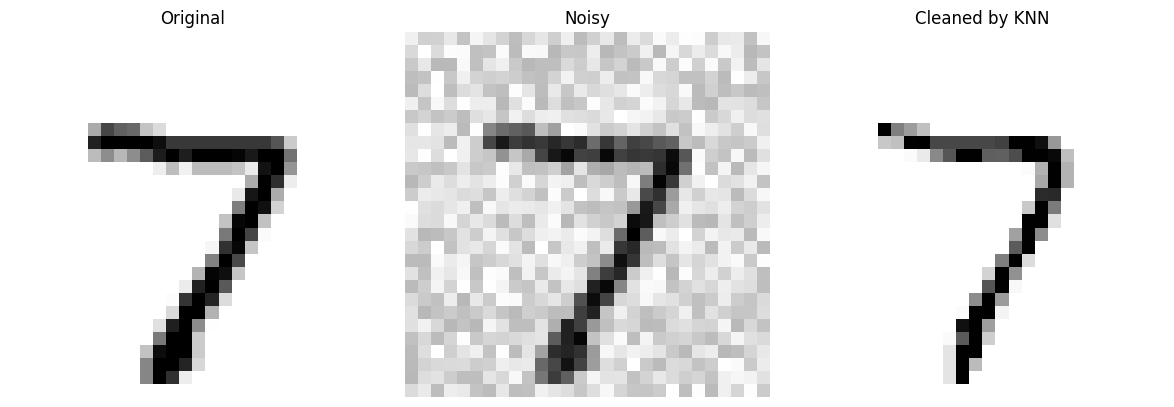


The classifier successfully removes much of the noise!


In [37]:
# Train a classifier to clean the images
print("Training noise removal classifier... This will take a while.")
knn_clf.fit(X_train_mod, y_train_mod)
print("Training complete!")

# Clean a noisy test image
clean_digit = knn_clf.predict([X_test_mod[0]])

# Visualize the result
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plot_digit(X_test[0])
plt.title("Original")

plt.subplot(1, 3, 2)
plot_digit(X_test_mod[0])
plt.title("Noisy")

plt.subplot(1, 3, 3)
plot_digit(clean_digit)
plt.title("Cleaned by KNN")

plt.tight_layout()
plt.show()

print("\nThe classifier successfully removes much of the noise!")

## Summary and Key Takeaways

In this notebook, we've covered:

1. **Binary Classification**: Simplifying multiclass problems into binary decisions

2. **Performance Metrics**:
   - **Accuracy** can be misleading with imbalanced datasets
   - **Precision**: How many positive predictions are correct?
   - **Recall**: How many actual positives are detected?
   - **F₁ Score**: Harmonic mean of precision and recall
   - **Confusion Matrix**: Detailed breakdown of predictions
   - **ROC Curve & AUC**: Overall classifier performance

3. **Precision/Recall Trade-off**: Adjusting thresholds to favor precision or recall

4. **Multiclass Classification**:
   - OvR (One-vs-Rest) and OvO (One-vs-One) strategies
   - Feature scaling significantly improves performance

5. **Error Analysis**: Understanding what types of mistakes the classifier makes

6. **Multilabel Classification**: Predicting multiple binary labels per instance

7. **Multioutput Classification**: Each label can have multiple possible values

### Next Steps:
- Try different classifiers (Random Forest, Neural Networks)
- Implement data augmentation (shifting, rotating images)
- Tune hyperparameters with GridSearchCV
- Try ensemble methods to combine multiple classifiers

## Exercises

Try these exercises to practice what you've learned:

1. **Achieve 97%+ accuracy**: Use `KNeighborsClassifier` with grid search to find optimal hyperparameters

2. **Data augmentation**: Write a function to shift images by one pixel in each direction, then retrain

3. **Titanic dataset**: Build a classifier to predict survival on the Titanic

4. **Spam classifier**: Build an email spam detection system using text classification techniques